# Tutorial: Garnet Port For Ariel Quantum Regression

Audience:
- Engineers working on `/Users/iwosmura/projects/hack4sages` who want one notebook to prepare validation runs for IQM Garnet from the saved Ariel checkpoint.

Prerequisites:
- Python 3.11 or 3.12
- The dependencies from `setup_garnet_env.sh`
- The saved checkpoint under `artifacts/ariel_quantum_best_v4_epoch6`
- The local Ariel dataset only when you want checkpoint-backed 8-qubit validation samples

Learning goals:
- Validate the local environment from inside the notebook
- Prepare 8-qubit Garnet-compatible validation circuits from Ariel samples
- Inspect dynamic layout selection and transpilation stats
- Run local and fake-backend dry validation
- Preview a real IQM validation submission without sending it


## Outline

1. Locate the repo and validate the Python environment
2. Import the Garnet helpers
3. Choose qubit count, backend mode, and validation split
4. Run preflight checks for checkpoint and dataset availability
5. Prepare either an 8-qubit validation run or a 12-qubit scaffold-only run
6. Inspect layout selection and transpilation details
7. Run local statevector and IQM fake-backend dry validation
8. Preview a real validation submission without sending it


In [16]:
from __future__ import annotations

from dataclasses import replace
from pathlib import Path
import importlib.util
import json
import sys


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / '.git').exists():
            return candidate
    raise RuntimeError('Could not find the repo root from the current working directory.')


REPO_ROOT_HINT = Path('/Users/iwosmura/projects/hack4sages')
REPO_ROOT = REPO_ROOT_HINT if (REPO_ROOT_HINT / '.git').exists() else find_repo_root(Path.cwd())
NOTEBOOKS_ROOT = REPO_ROOT / 'ariel' / 'models' / 'notebooks'
for path in (REPO_ROOT, NOTEBOOKS_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

NOTEBOOKS_ROOT


PosixPath('/Users/jkw/Documents/uni/axion/hack4sages/ariel/models/notebooks')

## Environment Check

This notebook is intended to be standalone inside the repo. The next cell checks that the key runtime dependencies are importable before any model code runs.


In [17]:
required_modules = {
    'torch': 'checkpoint loading and frozen classical inference',
    'qiskit': 'circuit construction and transpilation',
    'iqm': 'IQM fake/mock/facade/real backend integration',
}
missing = [name for name in required_modules if importlib.util.find_spec(name) is None]
if missing:
    details = ', '.join(f"{name} ({required_modules[name]})" for name in missing)
    raise RuntimeError(
        'Missing required modules: '
        + details
        + '. '
        + f'Run {NOTEBOOKS_ROOT / "garnet_ariel_quantum_regression" / "setup_garnet_env.sh"} first.'
    )

import importlib

garnet_pkg = importlib.import_module('garnet_ariel_quantum_regression')
for module_name in [
    'garnet_ariel_quantum_regression.backend',
    'garnet_ariel_quantum_regression.circuit',
    'garnet_ariel_quantum_regression.checkpoint',
    'garnet_ariel_quantum_regression.runtime',
    'garnet_ariel_quantum_regression.constants',
    'garnet_ariel_quantum_regression',
]:
    if module_name in sys.modules:
        importlib.reload(sys.modules[module_name])

garnet_pkg = importlib.import_module('garnet_ariel_quantum_regression')
from garnet_ariel_quantum_regression import (
    GarnetPortConfig,
    load_checkpoint_bundle,
    load_prepared_data,
    prepare_garnet_run,
    prepare_validation_split_run,
    resolve_split,
    run_iqm_execution,
    run_local_baseline,
    run_mock_evaluation,
)
from garnet_ariel_quantum_regression.constants import DEFAULT_CHECKPOINT_DIR

'Environment looks ready.'


'Environment looks ready.'

## Configuration

The notebook is set up for a two-stage workflow:
- start with `BACKEND_MODE='fake'` to validate circuits, layout selection, transpilation, and prediction flow locally
- switch to `BACKEND_MODE='real'` only after the fake Garnet run looks correct

This run is configured to use the standalone `8`-qubit ExoBiome hybrid weights at `ariel/models/weights/ariel_exobiome_8.pt`. During preflight, the notebook reconstructs a runnable checkpoint directory with matching scalers so the Garnet port can evaluate that export directly.


In [18]:
import getpass
import os
from dataclasses import asdict

N_QUBITS = 8
BACKEND_MODE = 'real'   # 'fake', 'mock', 'facade', or 'real'
SPLIT_NAME = 'validation'  # 'validation', 'holdout', or 'train'
MAX_SAMPLES = 2000         # Use None to reproduce the checkpoint's full validation RMSE.
SHOTS = 256
EVAL_SHOT_COUNTS = [256]
OPTIMIZATION_LEVEL = 1
SUBMIT_TO_IQM = True
DATA_ROOT = REPO_ROOT / 'ariel'
CHECKPOINT_FILE = REPO_ROOT / 'ariel' / 'models' / 'weights' / 'ariel_exobiome_8.pt'
CHECKPOINT_DIR = None      # Optional override: directory already containing best_model.pt, config.json, and scalers.json
RECONSTRUCT_SCALERS_IF_NEEDED = True
IQM_TOKEN_ENV_VAR = 'IQM_TOKEN'
IQM_TOKEN = os.environ.get(IQM_TOKEN_ENV_VAR)

if BACKEND_MODE == 'real' and not IQM_TOKEN:
    IQM_TOKEN = getpass.getpass('Enter IQM Resonance token: ').strip()
    if not IQM_TOKEN:
        raise RuntimeError('A non-empty IQM token is required for BACKEND_MODE=\'real\'.')

checkpoint_source = Path(CHECKPOINT_DIR).expanduser().resolve() if CHECKPOINT_DIR else Path(CHECKPOINT_FILE).expanduser().resolve()
config = GarnetPortConfig(
    checkpoint_dir=checkpoint_source,
    n_qubits=N_QUBITS,
    backend_mode=BACKEND_MODE,
    backend_token=IQM_TOKEN,
    shots=SHOTS,
    optimization_level=OPTIMIZATION_LEVEL,
    max_samples=MAX_SAMPLES,
    submit_to_iqm=SUBMIT_TO_IQM,
)
config_display = asdict(config)
config_display['checkpoint_dir'] = str(config.checkpoint_dir)
config_display['backend_token'] = '<set>' if config.backend_token else '<unset>'
config_display['reconstruct_scalers_if_needed'] = RECONSTRUCT_SCALERS_IF_NEEDED
config_display


Enter IQM Resonance token:  ········


{'checkpoint_dir': '/Users/jkw/Documents/uni/axion/hack4sages/ariel/models/weights/ariel_exobiome_8.pt',
 'n_qubits': 8,
 'backend_mode': 'real',
 'backend_url': 'https://resonance.meetiqm.com',
 'backend_alias': 'garnet',
 'backend_token': '<set>',
 'shots': 256,
 'optimization_level': 1,
 'layout_policy': 'dynamic',
 'selected_physical_qubits': None,
 'submit_to_iqm': True,
 'max_samples': 2000,
 'reconstruct_scalers_if_needed': True}

## Preflight Checks

This confirms the saved checkpoint exists. For 8-qubit validation, it also checks that the local Ariel dataset is available before trying to prepare samples.


In [19]:
import shutil

from models.ariel_quantum_regression.dataset import prepare_data


def discover_saved_checkpoints() -> list[dict[str, object]]:
    saved: list[dict[str, object]] = []
    outputs_root = NOTEBOOKS_ROOT / 'outputs'
    if not outputs_root.exists():
        return saved

    for best_model_path in sorted(outputs_root.glob('**/stage2_hybrid/best_model.pt')):
        checkpoint_dir = best_model_path.parent
        qnn_qubits = None
        config_path = checkpoint_dir / 'config.json'
        if config_path.exists():
            try:
                qnn_qubits = json.loads(config_path.read_text()).get('qnn_qubits')
            except json.JSONDecodeError:
                qnn_qubits = None
        saved.append({'checkpoint_dir': checkpoint_dir, 'qnn_qubits': qnn_qubits})
    return saved


def hydrate_standalone_checkpoint(checkpoint_file: Path, data_root: Path, cache_root: Path) -> tuple[Path, dict[str, object]]:
    checkpoint_path = Path(checkpoint_file).expanduser().resolve()
    if checkpoint_path.suffix != '.pt':
        raise ValueError(f'Expected a standalone .pt checkpoint file, got {checkpoint_path}.')
    if not checkpoint_path.exists():
        raise FileNotFoundError(f'Standalone checkpoint file not found: {checkpoint_path}')

    import torch

    payload = torch.load(checkpoint_path, map_location='cpu')
    embedded_config = payload.get('config')
    if not isinstance(embedded_config, dict):
        raise RuntimeError(f'The standalone checkpoint at {checkpoint_path} does not contain an embedded config dictionary.')
    embedded_best_val_rmse = payload.get('best_val_rmse')

    hydrated_dir = cache_root / checkpoint_path.stem
    hydrated_dir.mkdir(parents=True, exist_ok=True)
    hydrated_best_model = hydrated_dir / 'best_model.pt'
    if not hydrated_best_model.exists():
        shutil.copy2(checkpoint_path, hydrated_best_model)

    (hydrated_dir / 'config.json').write_text(json.dumps(embedded_config, indent=2) + '\n')
    scalers_path = hydrated_dir / 'scalers.json'
    scalers_reconstructed = False

    if not scalers_path.exists():
        if not RECONSTRUCT_SCALERS_IF_NEEDED:
            raise FileNotFoundError(
                f'No scalers.json found for {checkpoint_path}. Enable RECONSTRUCT_SCALERS_IF_NEEDED or supply CHECKPOINT_DIR instead.'
            )
        if not data_root.exists():
            raise RuntimeError(
                f'Cannot reconstruct scalers for {checkpoint_path} because DATA_ROOT does not exist: {data_root}'
            )

        prepared = prepare_data(
            data_root=Path(data_root),
            output_dir=hydrated_dir,
            prepared_cache_dir=hydrated_dir / 'prepared_cache',
            seed=int(embedded_config.get('seed', 42)),
            train_limit=embedded_config.get('train_limit'),
            val_limit=embedded_config.get('val_limit'),
            holdout_limit=embedded_config.get('holdout_limit'),
            test_limit=embedded_config.get('test_limit'),
        )
        scalers_payload = {
            'aux_scaler': prepared.aux_scaler.state_dict(),
            'target_scaler': prepared.target_scaler.state_dict(),
            'spectral_scaler': prepared.spectral_scaler.state_dict(),
        }
        scalers_path.write_text(json.dumps(scalers_payload, indent=2) + '\n')
        scalers_reconstructed = True

    return hydrated_dir, {
        'source_checkpoint_file': str(checkpoint_path),
        'hydrated_checkpoint_dir': str(hydrated_dir),
        'scalers_path': str(scalers_path),
        'scalers_reconstructed': scalers_reconstructed,
        'embedded_qnn_qubits': embedded_config.get('qnn_qubits'),
        'embedded_qnn_depth': embedded_config.get('qnn_depth'),
        'embedded_best_val_rmse': None if embedded_best_val_rmse is None else float(embedded_best_val_rmse),
        'embedded_split_seed': embedded_config.get('seed'),
        'embedded_train_limit': embedded_config.get('train_limit'),
        'embedded_val_limit': embedded_config.get('val_limit'),
        'embedded_holdout_limit': embedded_config.get('holdout_limit'),
    }


saved_checkpoints = discover_saved_checkpoints()
dataset_ok = DATA_ROOT.exists()
requested_checkpoint_source = Path(config.checkpoint_dir).expanduser().resolve()
checkpoint_resolution = {
    'requested_checkpoint_source': str(requested_checkpoint_source),
}

if requested_checkpoint_source.suffix == '.pt':
    resolved_checkpoint_dir, hydration_summary = hydrate_standalone_checkpoint(
        checkpoint_file=requested_checkpoint_source,
        data_root=DATA_ROOT,
        cache_root=NOTEBOOKS_ROOT / 'outputs' / 'garnet_ariel_quantum_regression' / 'hydrated_checkpoints',
    )
    checkpoint_resolution.update(hydration_summary)
    config = replace(config, checkpoint_dir=resolved_checkpoint_dir)
else:
    resolved_checkpoint_dir = requested_checkpoint_source
    matching = [entry['checkpoint_dir'] for entry in saved_checkpoints if entry['qnn_qubits'] == N_QUBITS]
    if CHECKPOINT_DIR is None and not (resolved_checkpoint_dir / 'best_model.pt').exists() and matching:
        resolved_checkpoint_dir = Path(matching[-1])
        config = replace(config, checkpoint_dir=resolved_checkpoint_dir)

if not (resolved_checkpoint_dir / 'best_model.pt').exists():
    available = [
        {
            'checkpoint_dir': str(entry['checkpoint_dir']),
            'qnn_qubits': entry['qnn_qubits'],
        }
        for entry in saved_checkpoints[-5:]
    ]
    raise FileNotFoundError(
        f'No {N_QUBITS}-qubit checkpoint bundle was found at {resolved_checkpoint_dir}. '
        + 'Set CHECKPOINT_DIR to a directory containing best_model.pt, config.json, and scalers.json '
        + 'or point CHECKPOINT_FILE at a standalone .pt export. '
        + 'Recent saved checkpoints: '
        + json.dumps(available, indent=2)
    )

if BACKEND_MODE == 'real' and not config.backend_token:
    raise RuntimeError(
        'BACKEND_MODE=\'real\' requires an IQM token. Set the IQM_TOKEN environment variable or enter it in the config cell.'
    )

CHECKPOINT = load_checkpoint_bundle(resolved_checkpoint_dir)
checkpoint_ok = CHECKPOINT.checkpoint_dir.exists()

summary = {
    'checkpoint_dir': str(CHECKPOINT.checkpoint_dir),
    'checkpoint_exists': checkpoint_ok,
    'checkpoint_qubits': CHECKPOINT.qnn_qubits,
    'dataset_dir': str(DATA_ROOT),
    'dataset_exists': dataset_ok,
    'requested_qubits': N_QUBITS,
    'backend_mode': BACKEND_MODE,
    'using_iqm_token': bool(config.backend_token),
    'max_samples': MAX_SAMPLES,
    **checkpoint_resolution,
}
print(json.dumps(summary, indent=2))

if summary.get('embedded_best_val_rmse') is not None and MAX_SAMPLES is not None:
    print(
        'Note: embedded_best_val_rmse comes from the full validation split, '
        f'but MAX_SAMPLES={MAX_SAMPLES} loads only a subset, so the local RMSE will not match exactly.'
    )

if CHECKPOINT.qnn_qubits != N_QUBITS:
    raise RuntimeError(
        f'The selected checkpoint uses {CHECKPOINT.qnn_qubits} qubits but the notebook is configured for {N_QUBITS}. '
        + 'Either change N_QUBITS to match or choose a different checkpoint.'
    )

if N_QUBITS == 8 and not dataset_ok:
    raise RuntimeError('8-qubit validation mode needs the local Ariel dataset to prepare validation samples and reconstruct scalers when needed.')


{
  "checkpoint_dir": "/Users/jkw/Documents/uni/axion/hack4sages/ariel/models/notebooks/outputs/garnet_ariel_quantum_regression/hydrated_checkpoints/ariel_exobiome_8",
  "checkpoint_exists": true,
  "checkpoint_qubits": 8,
  "dataset_dir": "/Users/jkw/Documents/uni/axion/hack4sages/ariel",
  "dataset_exists": true,
  "requested_qubits": 8,
  "backend_mode": "real",
  "using_iqm_token": true,
  "max_samples": 2000,
  "requested_checkpoint_source": "/Users/jkw/Documents/uni/axion/hack4sages/ariel/models/weights/ariel_exobiome_8.pt",
  "source_checkpoint_file": "/Users/jkw/Documents/uni/axion/hack4sages/ariel/models/weights/ariel_exobiome_8.pt",
  "hydrated_checkpoint_dir": "/Users/jkw/Documents/uni/axion/hack4sages/ariel/models/notebooks/outputs/garnet_ariel_quantum_regression/hydrated_checkpoints/ariel_exobiome_8",
  "scalers_path": "/Users/jkw/Documents/uni/axion/hack4sages/ariel/models/notebooks/outputs/garnet_ariel_quantum_regression/hydrated_checkpoints/ariel_exobiome_8/scalers.json

## Load the Exact Saved Validation Split

This notebook uses the saved `val_dataset` membership files so the evaluation rows match the checkpoint's original train/validation/holdout split.

The spectra stay in `ariel/TrainingData/SpectralData.hdf5`; the CSVs here only provide the exact `planet_ID` membership plus auxiliary features and targets.


In [20]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
import torch

from IPython.display import display

from models.ariel_quantum_regression.constants import (
    AUX_COLUMNS,
    HDF5_GROUP_PREFIX,
    LOG10_AUX_COLUMNS,
    RAW_SPECTRAL_CHANNELS,
    TARGET_COLUMNS,
    WAVELENGTH_DATASET,
)
from models.ariel_quantum_regression.dataset import LabeledSplit, _normalize_sample_spectra
from garnet_ariel_quantum_regression.backend import resolve_iqm_backend
from garnet_ariel_quantum_regression.circuit import expectations_from_counts

VAL_DATASET_DIR = NOTEBOOKS_ROOT / 'garnet_ariel_quantum_regression' / 'val_dataset'
VAL_DATASET_MANIFEST = json.loads((VAL_DATASET_DIR / 'manifest.json').read_text())


def resolve_saved_split_name(split_name: str) -> str:
    normalized = split_name.strip().lower()
    aliases = {'val': 'validation', 'validation': 'validation', 'holdout': 'holdout', 'train': 'train'}
    if normalized not in aliases:
        raise ValueError("SPLIT_NAME must be one of: 'validation', 'val', 'holdout', 'train'.")
    return aliases[normalized]


def load_saved_labeled_split(
    split_name: str,
    data_root: Path,
    checkpoint_bundle,
    val_dataset_dir: Path,
    limit: int | None = None,
) -> LabeledSplit:
    resolved_split = resolve_saved_split_name(split_name)
    aux_frame = pd.read_csv(val_dataset_dir / f'{resolved_split}_auxiliary.csv')
    target_frame = pd.read_csv(val_dataset_dir / f'{resolved_split}_targets.csv')
    ids_frame = pd.read_csv(val_dataset_dir / f'{resolved_split}_planet_ids.csv')

    planet_ids = ids_frame['planet_ID'].astype(str).to_numpy(dtype='U32')
    aux_ids = aux_frame['planet_ID'].astype(str).to_numpy(dtype='U32')
    target_ids = target_frame['planet_ID'].astype(str).to_numpy(dtype='U32')
    if not np.array_equal(aux_ids, planet_ids) or not np.array_equal(target_ids, planet_ids):
        raise AssertionError('Saved validation split files are not aligned on planet_ID.')

    if limit is not None:
        take = min(int(limit), len(planet_ids))
        planet_ids = planet_ids[:take]
        aux_frame = aux_frame.iloc[:take].reset_index(drop=True)
        target_frame = target_frame.iloc[:take].reset_index(drop=True)

    spectral_path = Path(data_root) / 'TrainingData' / 'SpectralData.hdf5'
    spectra_raw = np.empty((len(planet_ids), 52, len(RAW_SPECTRAL_CHANNELS)), dtype=np.float32)
    with h5py.File(spectral_path, 'r') as handle:
        for row_index, planet_id in enumerate(planet_ids.tolist()):
            group = handle[f'{HDF5_GROUP_PREFIX}{planet_id}']
            for channel_index, channel_name in enumerate(RAW_SPECTRAL_CHANNELS):
                spectra_raw[row_index, :, channel_index] = np.asarray(group[channel_name][:], dtype=np.float32)

    aux_raw = aux_frame[AUX_COLUMNS].to_numpy(dtype=np.float32, copy=True)
    for column_index, column_name in enumerate(AUX_COLUMNS):
        if column_name in LOG10_AUX_COLUMNS:
            aux_raw[:, column_index] = np.log10(np.clip(aux_raw[:, column_index], 1.0e-12, None))

    target_raw = target_frame[TARGET_COLUMNS].to_numpy(dtype=np.float32, copy=True)
    sample_channel_indices = [RAW_SPECTRAL_CHANNELS.index(name) for name in ('instrument_spectrum', 'instrument_noise')]
    sample_spectra = np.transpose(spectra_raw[:, :, sample_channel_indices], (0, 2, 1)).astype(np.float32)
    sample_spectra = _normalize_sample_spectra(sample_spectra)

    return LabeledSplit(
        planet_ids=planet_ids,
        aux=torch.from_numpy(checkpoint_bundle.aux_scaler.transform(aux_raw)),
        spectra=torch.from_numpy(checkpoint_bundle.spectral_scaler.transform(sample_spectra)),
        targets=torch.from_numpy(checkpoint_bundle.target_scaler.transform(target_raw)),
        raw_targets=target_raw,
    )


resolved_split_name = resolve_saved_split_name(SPLIT_NAME)
validation_split = load_saved_labeled_split(
    split_name=resolved_split_name,
    data_root=DATA_ROOT,
    checkpoint_bundle=CHECKPOINT,
    val_dataset_dir=VAL_DATASET_DIR,
    limit=MAX_SAMPLES,
)
validation_dataset_summary = {
    'split_name': resolved_split_name,
    'rows_loaded': int(validation_split.rows),
    'split_rows_total': int(VAL_DATASET_MANIFEST['rows'][resolved_split_name]),
    'val_dataset_dir': str(VAL_DATASET_DIR),
    'spectral_hdf5': str(DATA_ROOT / 'TrainingData' / 'SpectralData.hdf5'),
}
print(json.dumps(validation_dataset_summary, indent=2))


{
  "split_name": "validation",
  "rows_loaded": 2000,
  "split_rows_total": 4142,
  "val_dataset_dir": "/Users/jkw/Documents/uni/axion/hack4sages/ariel/models/notebooks/garnet_ariel_quantum_regression/val_dataset",
  "spectral_hdf5": "/Users/jkw/Documents/uni/axion/hack4sages/ariel/TrainingData/SpectralData.hdf5"
}


## Prepare the Garnet Validation Run

This notebook prepares Garnet-compatible circuits directly from the exact saved split rows loaded from `val_dataset`.

The resulting `run` object contains the classical backbone outputs, bound quantum circuits, transpiled circuits, and the selected Garnet layout for the chosen split.


In [21]:
run = prepare_garnet_run(config, data_split=validation_split, split_label=resolved_split_name)
summary = {
    'split_name': resolved_split_name,
    'rows_prepared': int(len(run.planet_ids)) if run.planet_ids is not None else 0,
    'backend': run.backend_metadata,
    'layout': None if run.chosen_layout is None else {
        'logical_to_physical': run.chosen_layout.logical_to_physical,
        'ring_supported': run.chosen_layout.ring_supported,
        'degraded': run.chosen_layout.degraded,
        'reason': run.chosen_layout.reason,
    },
    'transpile_stats': run.transpile_stats,
}
print(json.dumps(summary, indent=2))


{
  "split_name": "validation",
  "rows_prepared": 2000,
  "backend": {
    "backend_mode": "real",
    "backend_name": "IQMBackend",
    "backend_alias": "garnet",
    "backend_url": "https://resonance.meetiqm.com"
  },
  "layout": {
    "logical_to_physical": [
      0,
      1,
      4,
      5,
      10,
      9,
      8,
      3
    ],
    "ring_supported": true,
    "degraded": false,
    "reason": "Selected a simple ring with the lowest aggregate CZ error score."
  },
  "transpile_stats": {
    "count": 2000,
    "depth_min": 50,
    "depth_max": 50,
    "widths": [
      20,
      20,
      20,
      20,
      20,
      20,
      20,
      20,
      20,
      20,
      20,
      20,
      20,
      20,
      20,
      20,
      20,
      20,
      20,
      20,
      20,
      20,
      20,
      20,
      20,
      20,
      20,
      20,
      20,
      20,
      20,
      20,
      20,
      20,
      20,
      20,
      20,
      20,
      20,
      20,
      20,
      20,


## Validation Metrics and Shot Sweep

This section mirrors the validation style in `model_evaluation.ipynb`:
- evaluate an exact local statevector baseline
- sweep fake-backend shot counts on the same transpiled circuits
- compare RMSE, MAE, and time per sample against the saved validation targets


[0/6 |   0.0%] starting validation pipeline
[1/6 |  16.7%] classical metrics ready
[2/6 |  33.3%] local statevector ready
  -> fake backend sweep 1/1 at 256 shots
[3/6 |  50.0%] finished fake backend at 256 shots
[4/6 |  66.7%] per-target metrics ready
[5/6 |  83.3%] prediction preview ready


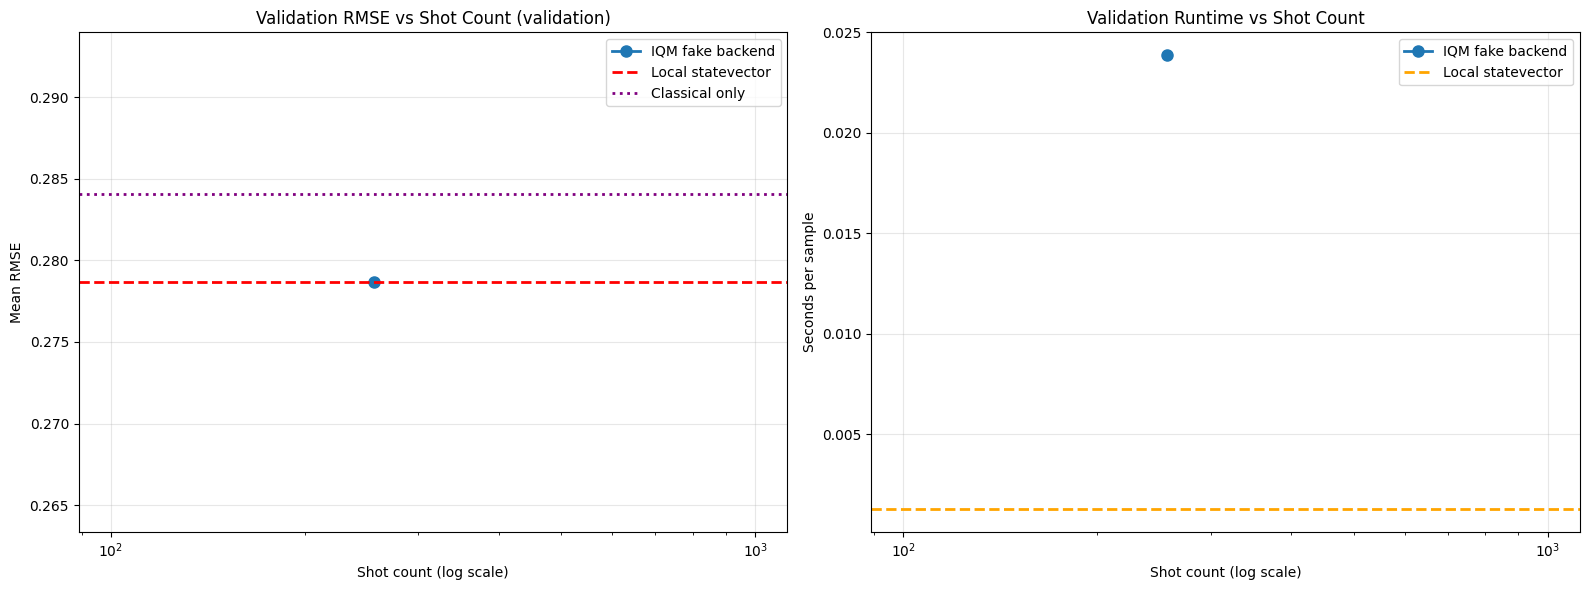

[6/6 | 100.0%] plots rendered
rows = 2000
first_planet_id = train12
selected_preview_shot = 256


,mode,shots,rows,rmse_mean,mae_mean,seconds_total,seconds_per_sample
0,classical_only,NaN,2000,0.284091,0.174520,NaN,NaN
1,local_statevector,0.0,2000,0.278651,0.173108,2.502571,0.001251
2,fake_256,256.0,2000,0.278666,0.173144,47.749726,0.023875


mode,classical_only,fake_256,local_statevector
target,,,
log_CH4,0.224302,0.222248,0.222248
log_CO,0.203195,0.197948,0.197955
log_CO2,0.225544,0.207164,0.207186
log_H2O,0.381731,0.388417,0.388421
log_NH3,0.385683,0.377553,0.377443


,planet_ID,true_log_H2O,classical_log_H2O,local_log_H2O,fake_256_log_H2O,true_log_CO2,classical_log_CO2,local_log_CO2,fake_256_log_CO2,true_log_CO,...,local_log_CO,fake_256_log_CO,true_log_CH4,classical_log_CH4,local_log_CH4,fake_256_log_CH4,true_log_NH3,classical_log_NH3,local_log_NH3,fake_256_log_NH3
0,train12,-5.504772,-5.566858,-5.526208,-5.527032,-7.244675,-7.424278,-7.478786,-7.478222,-3.691868,...,-4.350745,-4.349864,-4.678322,-5.032886,-5.035150,-5.034823,-5.181382,-5.595644,-5.588266,-5.588911
1,train28,-6.471501,-8.103284,-7.823103,-7.822502,-8.123703,-8.490354,-8.611173,-8.611289,-5.150521,...,-5.830991,-5.830219,-3.270543,-4.022777,-4.105840,-4.106122,-4.370298,-5.123376,-5.156330,-5.159209
2,train37,-3.884289,-3.530627,-3.547441,-3.547589,-8.632364,-7.886050,-8.013511,-8.014194,-4.525152,...,-4.214235,-4.214733,-4.089066,-3.947892,-3.962713,-3.963290,-4.206711,-4.041458,-3.935113,-3.933299
3,train46,-5.425148,-5.731209,-5.574651,-5.574821,-8.019904,-7.393957,-7.414755,-7.414783,-5.147952,...,-4.632159,-4.632593,-4.041214,-3.685778,-3.689543,-3.689776,-8.709106,-7.684021,-7.567184,-7.565044
4,train47,-3.862155,-4.272154,-4.240672,-4.241806,-5.673394,-5.349972,-5.332394,-5.334775,-5.583349,...,-4.507348,-4.506852,-3.940698,-4.037228,-4.032128,-4.032538,-8.278879,-8.067362,-7.872428,-7.869032


In [22]:
def summarize_regression_metrics(targets: np.ndarray, predictions: np.ndarray) -> dict[str, object]:
    residual = predictions - targets
    rmse_per_target = np.sqrt(np.mean(np.square(residual), axis=0))
    mae_per_target = np.mean(np.abs(residual), axis=0)
    return {
        'rmse_mean': float(rmse_per_target.mean()),
        'mae_mean': float(mae_per_target.mean()),
        'rmse_per_target': {name: float(value) for name, value in zip(TARGET_COLUMNS, rmse_per_target)},
        'mae_per_target': {name: float(value) for name, value in zip(TARGET_COLUMNS, mae_per_target)},
    }


def run_fake_backend_with_shots(prepared_run, shots: int, backend=None) -> tuple[np.ndarray, float]:
    active_backend = backend or resolve_iqm_backend('fake', prepared_run.config.backend_url, prepared_run.config.backend_alias)
    started_at = time.perf_counter()
    job = active_backend.run(prepared_run.transpiled_circuits, shots=int(shots))
    result = job.result()
    features = np.stack(
        [
            expectations_from_counts(result.get_counts(index), prepared_run.template.n_qubits)
            for index in range(len(prepared_run.transpiled_circuits))
        ],
        axis=0,
    ).astype(np.float32)
    combined_scaled = prepared_run.bridge.combine_predictions(prepared_run.head_context, features)
    predictions = prepared_run.checkpoint_bundle.target_scaler.inverse_transform(
        combined_scaled.detach().cpu().numpy().astype(np.float32)
    )
    return predictions, time.perf_counter() - started_at


def print_progress(step: int, total: int, label: str) -> None:
    percent = (100.0 * step / total) if total else 100.0
    print(f'[{step}/{total} | {percent:5.1f}%] {label}', flush=True)


target_values = validation_split.raw_targets[: len(run.planet_ids)]
shot_counts = sorted({int(SHOTS), *[int(value) for value in EVAL_SHOT_COUNTS]})
pipeline_steps = 5 + len(shot_counts)
current_step = 0
print_progress(current_step, pipeline_steps, 'starting validation pipeline')

classical_predictions = run.classical_predictions
classical_metrics = summarize_regression_metrics(target_values, classical_predictions)
current_step += 1
print_progress(current_step, pipeline_steps, 'classical metrics ready')

local_started_at = time.perf_counter()
local_predictions = run_local_baseline(run)
local_elapsed = time.perf_counter() - local_started_at
local_metrics = summarize_regression_metrics(target_values, local_predictions)
current_step += 1
print_progress(current_step, pipeline_steps, 'local statevector ready')

fake_backend = resolve_iqm_backend('fake', run.config.backend_url, run.config.backend_alias)
fake_results: list[dict[str, object]] = []
prediction_store: dict[str, np.ndarray] = {
    'classical_only': classical_predictions,
    'local_statevector': local_predictions,
}

for shot_index, shot_count in enumerate(shot_counts, start=1):
    print(f'  -> fake backend sweep {shot_index}/{len(shot_counts)} at {shot_count} shots', flush=True)
    fake_predictions, elapsed = run_fake_backend_with_shots(run, shot_count, backend=fake_backend)
    fake_metrics = summarize_regression_metrics(target_values, fake_predictions)
    prediction_store[f'fake_{shot_count}'] = fake_predictions
    fake_results.append(
        {
            'mode': f'fake_{shot_count}',
            'shots': int(shot_count),
            'rows': int(len(run.planet_ids)),
            'rmse_mean': fake_metrics['rmse_mean'],
            'mae_mean': fake_metrics['mae_mean'],
            'seconds_total': float(elapsed),
            'seconds_per_sample': float(elapsed / len(run.planet_ids)),
        }
    )
    current_step += 1
    print_progress(current_step, pipeline_steps, f'finished fake backend at {shot_count} shots')

validation_summary_frame = pd.DataFrame(
    [
        {
            'mode': 'classical_only',
            'shots': np.nan,
            'rows': int(len(run.planet_ids)),
            'rmse_mean': classical_metrics['rmse_mean'],
            'mae_mean': classical_metrics['mae_mean'],
            'seconds_total': np.nan,
            'seconds_per_sample': np.nan,
        },
        {
            'mode': 'local_statevector',
            'shots': 0,
            'rows': int(len(run.planet_ids)),
            'rmse_mean': local_metrics['rmse_mean'],
            'mae_mean': local_metrics['mae_mean'],
            'seconds_total': float(local_elapsed),
            'seconds_per_sample': float(local_elapsed / len(run.planet_ids)),
        },
        *fake_results,
    ]
)

per_target_rows: list[dict[str, object]] = []
for mode_name, predictions in prediction_store.items():
    metrics = summarize_regression_metrics(target_values, predictions)
    for target_name in TARGET_COLUMNS:
        per_target_rows.append(
            {
                'mode': mode_name,
                'target': target_name,
                'rmse': metrics['rmse_per_target'][target_name],
                'mae': metrics['mae_per_target'][target_name],
            }
        )
validation_per_target_frame = pd.DataFrame(per_target_rows)
current_step += 1
print_progress(current_step, pipeline_steps, 'per-target metrics ready')

selected_shot = SHOTS if SHOTS in shot_counts else shot_counts[-1]
selected_fake_predictions = prediction_store[f'fake_{selected_shot}']
validation_prediction_preview = pd.DataFrame({'planet_ID': run.planet_ids})
for target_index, target_name in enumerate(TARGET_COLUMNS):
    validation_prediction_preview[f'true_{target_name}'] = target_values[:, target_index]
    validation_prediction_preview[f'classical_{target_name}'] = classical_predictions[:, target_index]
    validation_prediction_preview[f'local_{target_name}'] = local_predictions[:, target_index]
    validation_prediction_preview[f'fake_{selected_shot}_{target_name}'] = selected_fake_predictions[:, target_index]
current_step += 1
print_progress(current_step, pipeline_steps, 'prediction preview ready')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.plot(
    [row['shots'] for row in fake_results],
    [row['rmse_mean'] for row in fake_results],
    'o-',
    linewidth=2,
    markersize=8,
    label='IQM fake backend',
)
ax1.axhline(local_metrics['rmse_mean'], color='red', linestyle='--', linewidth=2, label='Local statevector')
ax1.axhline(classical_metrics['rmse_mean'], color='purple', linestyle=':', linewidth=2, label='Classical only')
ax1.set_xscale('log')
ax1.set_xlabel('Shot count (log scale)')
ax1.set_ylabel('Mean RMSE')
ax1.set_title(f'Validation RMSE vs Shot Count ({resolved_split_name})')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(
    [row['shots'] for row in fake_results],
    [row['seconds_per_sample'] for row in fake_results],
    'o-',
    linewidth=2,
    markersize=8,
    label='IQM fake backend',
)
ax2.axhline(local_elapsed / len(run.planet_ids), color='orange', linestyle='--', linewidth=2, label='Local statevector')
ax2.set_xscale('log')
ax2.set_xlabel('Shot count (log scale)')
ax2.set_ylabel('Seconds per sample')
ax2.set_title('Validation Runtime vs Shot Count')
ax2.grid(True, alpha=0.3)
ax2.legend()
plt.tight_layout()
plt.show()
current_step += 1
print_progress(current_step, pipeline_steps, 'plots rendered')

print('rows =', len(run.planet_ids))
print('first_planet_id =', run.planet_ids[0])
print('selected_preview_shot =', selected_shot)
display(validation_summary_frame)
display(validation_per_target_frame.pivot(index='target', columns='mode', values='rmse'))
validation_prediction_preview.head()


## IQM Submission Status

For live hardware runs, this notebook batches the transpiled circuits into IQM jobs of at most `100` circuits each because Resonance rejects larger submissions.

When `BACKEND_MODE='real'` and `SUBMIT_TO_IQM=True`, the next cell prints the submitted IQM job IDs and their initial statuses.


In [23]:
MAX_CIRCUITS_PER_IQM_JOB = 100


def iter_circuit_chunks(circuits: list, chunk_size: int):
    for start in range(0, len(circuits), int(chunk_size)):
        stop = min(start + int(chunk_size), len(circuits))
        yield start, stop, circuits[start:stop]


if not run.config.submit_to_iqm:
    submission_response = {
        'submitted': False,
        'backend_name': run.backend_metadata.get('backend_name'),
        'backend_mode': run.backend_metadata.get('backend_mode'),
        'job_count': 0,
        'circuit_count': len(run.transpiled_circuits),
        'shots': run.config.shots,
    }
    submission_status = submission_response
else:
    active_backend = resolve_iqm_backend(
        run.config.backend_mode,
        run.config.backend_url,
        run.config.backend_alias,
        run.config.backend_token,
    )
    submitted_jobs: list[dict[str, object]] = []
    job_summaries: list[dict[str, object]] = []

    for chunk_index, (start, stop, circuit_chunk) in enumerate(
        iter_circuit_chunks(run.transpiled_circuits, MAX_CIRCUITS_PER_IQM_JOB),
        start=1,
    ):
        live_job = active_backend.run(circuit_chunk, shots=run.config.shots)
        summary = {
            'chunk_index': chunk_index,
            'job_id': live_job.job_id(),
            'status': getattr(live_job.status(), 'name', str(live_job.status())),
            'start_row': start,
            'stop_row': stop,
            'circuit_count': stop - start,
        }
        try:
            summary['queue_position'] = live_job.queue_position(refresh=True)
        except Exception as exc:
            summary['queue_position_error'] = str(exc)
        try:
            error_message = live_job.error_message()
            if error_message:
                summary['error_message'] = error_message
        except Exception as exc:
            summary['error_message_lookup_failed'] = str(exc)
        submitted_jobs.append(
            {
                'chunk_index': chunk_index,
                'start_row': start,
                'stop_row': stop,
                'circuit_count': stop - start,
                'job': live_job,
            }
        )
        job_summaries.append(summary)

    submission_response = {
        'submitted': True,
        'backend_name': run.backend_metadata.get('backend_name'),
        'backend_mode': run.backend_metadata.get('backend_mode'),
        'shots': run.config.shots,
        'circuit_count': len(run.transpiled_circuits),
        'chunk_size_limit': MAX_CIRCUITS_PER_IQM_JOB,
        'job_count': len(submitted_jobs),
        'jobs': submitted_jobs,
        'job_summaries': job_summaries,
    }
    submission_status = {
        key: value
        for key, value in submission_response.items()
        if key not in {'jobs'}
    }

print(json.dumps(submission_status, indent=2, default=str))
if submission_status.get('submitted', False):
    display(pd.DataFrame(submission_status['job_summaries']))
submission_status


{
  "submitted": true,
  "backend_name": "IQMBackend",
  "backend_mode": "real",
  "shots": 256,
  "circuit_count": 2000,
  "chunk_size_limit": 100,
  "job_count": 20,
  "job_summaries": [
    {
      "chunk_index": 1,
      "job_id": "019ce0b2-aef3-72f3-92aa-77d97a6cca0f",
      "status": "QUEUED",
      "start_row": 0,
      "stop_row": 100,
      "circuit_count": 100,
      "queue_position": null
    },
    {
      "chunk_index": 2,
      "job_id": "019ce0b2-b716-79d1-8046-0f0f0986d641",
      "status": "QUEUED",
      "start_row": 100,
      "stop_row": 200,
      "circuit_count": 100,
      "queue_position": null
    },
    {
      "chunk_index": 3,
      "job_id": "019ce0b2-bff5-7383-a746-8cb1f13d3eb7",
      "status": "QUEUED",
      "start_row": 200,
      "stop_row": 300,
      "circuit_count": 100,
      "queue_position": null
    },
    {
      "chunk_index": 4,
      "job_id": "019ce0b2-c8bf-7fa0-ac20-6ea00bdcbb0e",
      "status": "QUEUED",
      "start_row": 300,
      "s

,chunk_index,job_id,status,start_row,stop_row,circuit_count,queue_position
0,1,019ce0b2-aef3-72f3-92aa-77d97a6cca0f,QUEUED,0,100,100,None
1,2,019ce0b2-b716-79d1-8046-0f0f0986d641,QUEUED,100,200,100,None
2,3,019ce0b2-bff5-7383-a746-8cb1f13d3eb7,QUEUED,200,300,100,None
3,4,019ce0b2-c8bf-7fa0-ac20-6ea00bdcbb0e,QUEUED,300,400,100,None
4,5,019ce0b2-d056-77e2-a5be-c2049b69e1b1,QUEUED,400,500,100,None
5,6,019ce0b2-d774-7250-a803-bf3828b5a0fd,QUEUED,500,600,100,None
6,7,019ce0b2-de09-78d1-ac68-c3ada6e3e00a,QUEUED,600,700,100,None
7,8,019ce0b2-e50a-7221-8859-488aec242c26,QUEUED,700,800,100,None
8,9,019ce0b2-ec53-7a32-b8bb-4a58a3e18eb1,QUEUED,800,900,100,None
9,10,019ce0b2-f499-7210-9bc0-1c8dfaa5e2c8,QUEUED,900,1000,100,None


{'submitted': True,
 'backend_name': 'IQMBackend',
 'backend_mode': 'real',
 'shots': 256,
 'circuit_count': 2000,
 'chunk_size_limit': 100,
 'job_count': 20,
 'job_summaries': [{'chunk_index': 1,
   'job_id': '019ce0b2-aef3-72f3-92aa-77d97a6cca0f',
   'status': 'QUEUED',
   'start_row': 0,
   'stop_row': 100,
   'circuit_count': 100,
   'queue_position': None},
  {'chunk_index': 2,
   'job_id': '019ce0b2-b716-79d1-8046-0f0f0986d641',
   'status': 'QUEUED',
   'start_row': 100,
   'stop_row': 200,
   'circuit_count': 100,
   'queue_position': None},
  {'chunk_index': 3,
   'job_id': '019ce0b2-bff5-7383-a746-8cb1f13d3eb7',
   'status': 'QUEUED',
   'start_row': 200,
   'stop_row': 300,
   'circuit_count': 100,
   'queue_position': None},
  {'chunk_index': 4,
   'job_id': '019ce0b2-c8bf-7fa0-ac20-6ea00bdcbb0e',
   'status': 'QUEUED',
   'start_row': 300,
   'stop_row': 400,
   'circuit_count': 100,
   'queue_position': None},
  {'chunk_index': 5,
   'job_id': '019ce0b2-d056-77e2-a5be-c20

## IQM Hardware Results and Interpretation

This section waits for the submitted IQM job to finish. If the job reaches `DONE`, it converts the returned counts into expectation features, produces real hardware predictions, and appends them to the same validation summaries used for the fake/local paths.


IQM job chunks:   0%|          | 0/20 [00:00<?, ?chunk/s]

{
  "job_count": 20,
  "elapsed_seconds": 29.981910041999072
}


,chunk_index,job_id,start_row,stop_row,circuit_count,final_status,elapsed_seconds
0,1,019ce0b2-aef3-72f3-92aa-77d97a6cca0f,0,100,100,DONE,0.149652
1,2,019ce0b2-b716-79d1-8046-0f0f0986d641,100,200,100,DONE,0.180022
2,3,019ce0b2-bff5-7383-a746-8cb1f13d3eb7,200,300,100,DONE,0.142242
3,4,019ce0b2-c8bf-7fa0-ac20-6ea00bdcbb0e,300,400,100,DONE,0.139353
4,5,019ce0b2-d056-77e2-a5be-c2049b69e1b1,400,500,100,DONE,0.142553
5,6,019ce0b2-d774-7250-a803-bf3828b5a0fd,500,600,100,DONE,0.143696
6,7,019ce0b2-de09-78d1-ac68-c3ada6e3e00a,600,700,100,DONE,0.147422
7,8,019ce0b2-e50a-7221-8859-488aec242c26,700,800,100,DONE,0.144889
8,9,019ce0b2-ec53-7a32-b8bb-4a58a3e18eb1,800,900,100,DONE,0.137198
9,10,019ce0b2-f499-7210-9bc0-1c8dfaa5e2c8,900,1000,100,DONE,0.144067


,chunk_index,job_id,elapsed_seconds,status,queue_position
0,1,019ce0b2-aef3-72f3-92aa-77d97a6cca0f,0.149151,DONE,None
1,2,019ce0b2-b716-79d1-8046-0f0f0986d641,0.164464,DONE,None
2,3,019ce0b2-bff5-7383-a746-8cb1f13d3eb7,0.141894,DONE,None
3,4,019ce0b2-c8bf-7fa0-ac20-6ea00bdcbb0e,0.138985,DONE,None
4,5,019ce0b2-d056-77e2-a5be-c2049b69e1b1,0.142166,DONE,None
5,6,019ce0b2-d774-7250-a803-bf3828b5a0fd,0.143295,DONE,None
6,7,019ce0b2-de09-78d1-ac68-c3ada6e3e00a,0.147045,DONE,None
7,8,019ce0b2-e50a-7221-8859-488aec242c26,0.144549,DONE,None
8,9,019ce0b2-ec53-7a32-b8bb-4a58a3e18eb1,0.136789,DONE,None
9,10,019ce0b2-f499-7210-9bc0-1c8dfaa5e2c8,0.143684,DONE,None


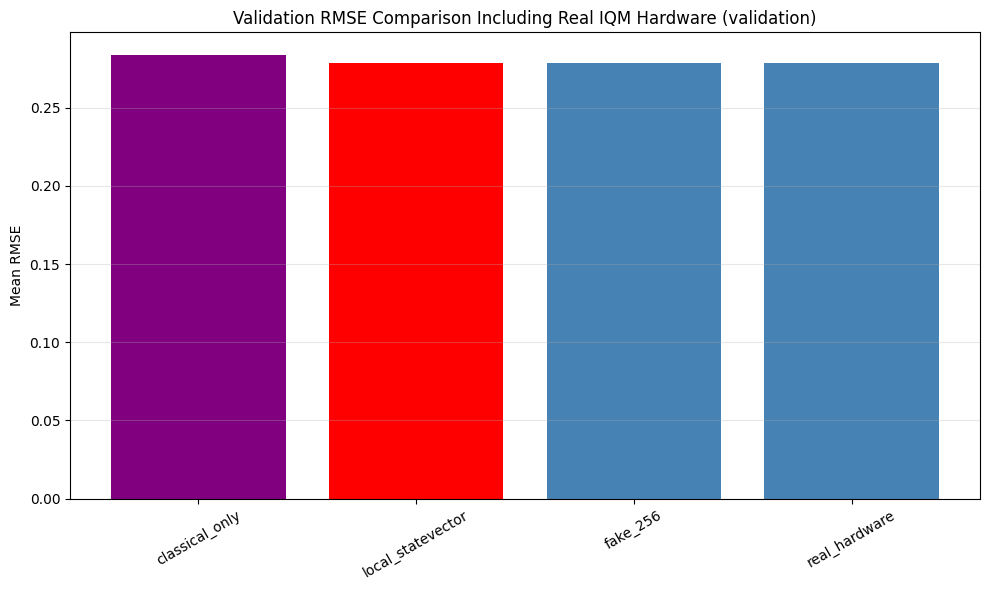

,mode,shots,rows,rmse_mean,mae_mean,seconds_total,seconds_per_sample
0,classical_only,NaN,2000,0.284091,0.174520,NaN,NaN
1,local_statevector,0.0,2000,0.278651,0.173108,2.502571,0.001251
2,fake_256,256.0,2000,0.278666,0.173144,47.749726,0.023875
3,real_hardware,256.0,2000,0.278756,0.173304,29.981910,0.014991


mode,classical_only,fake_256,local_statevector,real_hardware
target,,,,
log_CH4,0.224302,0.222248,0.222248,0.222266
log_CO,0.203195,0.197948,0.197955,0.197823
log_CO2,0.225544,0.207164,0.207186,0.207104
log_H2O,0.381731,0.388417,0.388421,0.388699
log_NH3,0.385683,0.377553,0.377443,0.377888


,planet_ID,true_log_H2O,classical_log_H2O,local_log_H2O,fake_256_log_H2O,true_log_CO2,classical_log_CO2,local_log_CO2,fake_256_log_CO2,true_log_CO,...,fake_256_log_CH4,true_log_NH3,classical_log_NH3,local_log_NH3,fake_256_log_NH3,real_256_log_H2O,real_256_log_CO2,real_256_log_CO,real_256_log_CH4,real_256_log_NH3
0,train12,-5.504772,-5.566858,-5.526208,-5.527032,-7.244675,-7.424278,-7.478786,-7.478222,-3.691868,...,-5.034823,-5.181382,-5.595644,-5.588266,-5.588911,-5.529183,-7.478020,-4.350435,-5.035025,-5.586410
1,train28,-6.471501,-8.103284,-7.823103,-7.822502,-8.123703,-8.490354,-8.611173,-8.611289,-5.150521,...,-4.106122,-4.370298,-5.123376,-5.156330,-5.159209,-7.826043,-8.614770,-5.830104,-4.105659,-5.154521
2,train37,-3.884289,-3.530627,-3.547441,-3.547589,-8.632364,-7.886050,-8.013511,-8.014194,-4.525152,...,-3.963290,-4.206711,-4.041458,-3.935113,-3.933299,-3.550165,-8.015714,-4.213033,-3.963323,-3.928881
3,train46,-5.425148,-5.731209,-5.574651,-5.574821,-8.019904,-7.393957,-7.414755,-7.414783,-5.147952,...,-3.689776,-8.709106,-7.684021,-7.567184,-7.565044,-5.576973,-7.418120,-4.631983,-3.689416,-7.559146
4,train47,-3.862155,-4.272154,-4.240672,-4.241806,-5.673394,-5.349972,-5.332394,-5.334775,-5.583349,...,-4.032538,-8.278879,-8.067362,-7.872428,-7.869032,-4.242197,-5.336476,-4.505565,-4.033226,-7.863602


In [24]:
from tqdm.auto import tqdm

LIVE_JOB_TIMEOUT_SECONDS = 1800
LIVE_STATUS_POLL_SECONDS = 5

if not submission_response.get('submitted', False):
    raise RuntimeError('No live IQM job was submitted. Set BACKEND_MODE=\'real\' and SUBMIT_TO_IQM=True first.')

submitted_jobs = submission_response.get('jobs')
if not submitted_jobs:
    raise RuntimeError('The submission cell did not return any IQM jobs to monitor.')

status_history: list[dict[str, object]] = []
chunk_summaries: list[dict[str, object]] = []
hardware_features = np.empty((len(run.transpiled_circuits), run.template.n_qubits), dtype=np.float32)
overall_started_at = time.perf_counter()
chunk_progress = tqdm(submitted_jobs, desc='IQM job chunks', unit='chunk')

for job_entry in chunk_progress:
    live_job = job_entry['job']
    chunk_index = int(job_entry['chunk_index'])
    start_row = int(job_entry['start_row'])
    stop_row = int(job_entry['stop_row'])
    job_started_at = time.perf_counter()
    last_status_key = None

    while True:
        overall_elapsed = time.perf_counter() - overall_started_at
        status_obj = live_job.status()
        status_name = getattr(status_obj, 'name', str(status_obj))
        queue_position = None
        queue_position_error = None
        try:
            queue_position = live_job.queue_position(refresh=True)
        except Exception as exc:
            queue_position_error = str(exc)

        status_key = (status_name, queue_position)
        if status_key != last_status_key:
            snapshot = {
                'chunk_index': chunk_index,
                'job_id': live_job.job_id(),
                'elapsed_seconds': float(time.perf_counter() - job_started_at),
                'status': status_name,
                'queue_position': queue_position,
            }
            if queue_position_error is not None:
                snapshot['queue_position_error'] = queue_position_error
            status_history.append(snapshot)
            last_status_key = status_key

        chunk_progress.set_postfix({'chunk': f'{chunk_index}/{len(submitted_jobs)}', 'status': status_name, 'queue': queue_position})
        if status_name in {'DONE', 'ERROR', 'CANCELLED'}:
            break
        if overall_elapsed >= LIVE_JOB_TIMEOUT_SECONDS:
            raise TimeoutError(f'IQM jobs did not finish within {LIVE_JOB_TIMEOUT_SECONDS} seconds.')
        time.sleep(LIVE_STATUS_POLL_SECONDS)

    chunk_summary = {
        'chunk_index': chunk_index,
        'job_id': live_job.job_id(),
        'start_row': start_row,
        'stop_row': stop_row,
        'circuit_count': stop_row - start_row,
        'final_status': status_name,
        'elapsed_seconds': float(time.perf_counter() - job_started_at),
    }
    try:
        error_message = live_job.error_message()
        if error_message:
            chunk_summary['error_message'] = error_message
    except Exception as exc:
        chunk_summary['error_message_lookup_failed'] = str(exc)
    chunk_summaries.append(chunk_summary)

    if status_name != 'DONE':
        continue

    remaining_timeout = max(1.0, LIVE_JOB_TIMEOUT_SECONDS - (time.perf_counter() - overall_started_at))
    hardware_result = live_job.result(timeout=remaining_timeout)
    chunk_features = np.stack(
        [
            expectations_from_counts(hardware_result.get_counts(index), run.template.n_qubits)
            for index in range(stop_row - start_row)
        ],
        axis=0,
    ).astype(np.float32)
    hardware_features[start_row:stop_row] = chunk_features

chunk_progress.close()

overall_elapsed = time.perf_counter() - overall_started_at
chunk_summary_frame = pd.DataFrame(chunk_summaries)
status_history_frame = pd.DataFrame(status_history)
print(json.dumps({'job_count': len(chunk_summaries), 'elapsed_seconds': float(overall_elapsed)}, indent=2))
display(chunk_summary_frame)
display(status_history_frame)

failed_chunks = chunk_summary_frame[chunk_summary_frame['final_status'] != 'DONE']
if not failed_chunks.empty:
    failed_job_ids = ', '.join(failed_chunks['job_id'].astype(str).tolist())
    raise RuntimeError(
        'One or more IQM job chunks failed; see the chunk summary above for job IDs and server error messages. '
        + f'Failed jobs: {failed_job_ids}'
    )

real_combined_scaled = run.bridge.combine_predictions(run.head_context, hardware_features)
real_predictions = run.checkpoint_bundle.target_scaler.inverse_transform(
    real_combined_scaled.detach().cpu().numpy().astype(np.float32)
)
real_metrics = summarize_regression_metrics(target_values, real_predictions)
prediction_store['real_hardware'] = real_predictions

validation_summary_with_real = pd.concat(
    [
        validation_summary_frame,
        pd.DataFrame(
            [
                {
                    'mode': 'real_hardware',
                    'shots': run.config.shots,
                    'rows': int(len(run.planet_ids)),
                    'rmse_mean': real_metrics['rmse_mean'],
                    'mae_mean': real_metrics['mae_mean'],
                    'seconds_total': float(overall_elapsed),
                    'seconds_per_sample': float(overall_elapsed / len(run.planet_ids)),
                }
            ]
        ),
    ],
    ignore_index=True,
)

real_per_target_rows = [
    {
        'mode': 'real_hardware',
        'target': target_name,
        'rmse': real_metrics['rmse_per_target'][target_name],
        'mae': real_metrics['mae_per_target'][target_name],
    }
    for target_name in TARGET_COLUMNS
]
validation_per_target_with_real = pd.concat(
    [validation_per_target_frame, pd.DataFrame(real_per_target_rows)],
    ignore_index=True,
)

validation_prediction_preview_with_real = validation_prediction_preview.copy()
for target_index, target_name in enumerate(TARGET_COLUMNS):
    validation_prediction_preview_with_real[f'real_{run.config.shots}_{target_name}'] = real_predictions[:, target_index]

fig, ax = plt.subplots(figsize=(10, 6))
comparison_rows = validation_summary_with_real.dropna(subset=['rmse_mean']).copy()
comparison_rows['label'] = comparison_rows['mode']
ax.bar(comparison_rows['label'], comparison_rows['rmse_mean'], color=['purple', 'red', 'steelblue', 'steelblue', 'steelblue', 'green'][: len(comparison_rows)])
ax.set_ylabel('Mean RMSE')
ax.set_title(f'Validation RMSE Comparison Including Real IQM Hardware ({resolved_split_name})')
ax.tick_params(axis='x', rotation=30)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

display(validation_summary_with_real)
display(validation_per_target_with_real.pivot(index='target', columns='mode', values='rmse'))
validation_prediction_preview_with_real.head()


## Pitfalls and Extensions

Common pitfalls:
- `SPLIT_NAME='train'` is fine for local validation, but live submission should stay on `validation` or `holdout` only.
- `CHECKPOINT_DIR` must match `N_QUBITS`; otherwise the notebook will stop during preflight.
- `BACKEND_MODE='real'` still requires valid IQM access once `SUBMIT_TO_IQM=True`.

Useful extensions:
- Increase `MAX_SAMPLES` toward the full saved split to measure prediction stability at larger batch sizes.
- Compare `validation` versus `holdout` in the same notebook by only changing `SPLIT_NAME`.
- Expand `EVAL_SHOT_COUNTS` when you want a denser shot-to-error curve.


In [ ]:
# Optional inspection scaffold
if run.transpiled_circuits:
    first_circuit = run.transpiled_circuits[0]
    print(first_circuit)
else:
    print('No transpiled circuits are available.')
